## **Importing Libraries**

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
from matplotlib import pyplot as plt
%matplotlib inline

In [ ]:
sns.set(style="whitegrid")

## **Loading the Dataset**

In [ ]:
df = pd.read_csv('netflix_titles.csv')

In [ ]:
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [ ]:
df.describe()

,release_year
count,8807.000000
mean,2014.180198
std,8.819312
min,1925.000000
25%,2013.000000
50%,2017.000000
75%,2019.000000
max,2021.000000


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB


In [ ]:
df.isnull().sum()

,0
show_id,0
type,0
title,0
director,2634
cast,825
country,831
date_added,10
release_year,0
rating,4
duration,3


## **Replacing Null Values**

In [ ]:
df['director'].fillna("Unknown", inplace=True)
df['cast'].fillna("Unknown", inplace=True)
df['country'].fillna("Unknown", inplace=True)
df['rating'].fillna("UR", inplace=True)

/tmp/ipykernel_1316/2229161325.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['director'].fillna("Unknown", inplace=True)
/tmp/ipykernel_1316/2229161325.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try us

## **For Date, Removing the missing rows and extracting Month and Year**

In [ ]:
df['date_added'].isna().sum()

np.int64(10)

In [ ]:
df = df.dropna(subset=['date_added'])

In [ ]:
df['date_added'].isna().sum()

np.int64(0)

In [ ]:
df['date_added'] = df['date_added'].str.strip()
df['date_added'] = pd.to_datetime(df['date_added'])
df['year_added'] = df['date_added'].dt.year
df['month_added'] = df['date_added'].dt.month

## **Correcting the Value Mismatch of the Data**

In [ ]:
# Find rows where rating contains 'min'
mask = df['rating'].str.contains('min', na=False)

# Move them to duration column
df.loc[mask, 'duration'] = df.loc[mask, 'rating']

# Set rating as NaN for those rows
df.loc[mask, 'rating'] = np.nan

## **Graph showing Distribution of Movies vs TV Shows**

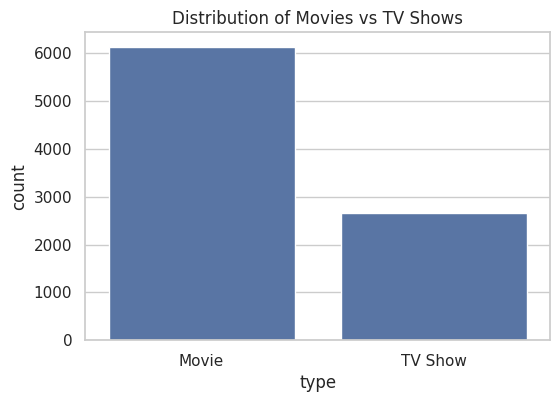

In [ ]:
plt.figure(figsize=(6,4))
sns.countplot(data=df, x='type')
plt.title("Distribution of Movies vs TV Shows")
plt.show()

## **Graph showing growth of Content added every year on Netflix**

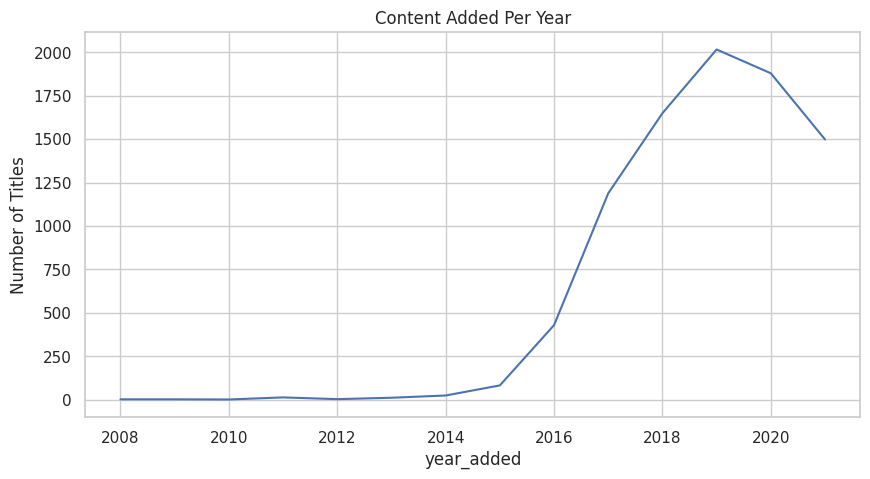

In [ ]:
content_growth = df.groupby('year_added')['show_id'].count()

plt.figure(figsize=(10,5))
content_growth.plot()
plt.title("Content Added Per Year")
plt.ylabel("Number of Titles")
plt.show()

## **Graph showing Top 10 Countries with the Highest Content Production**

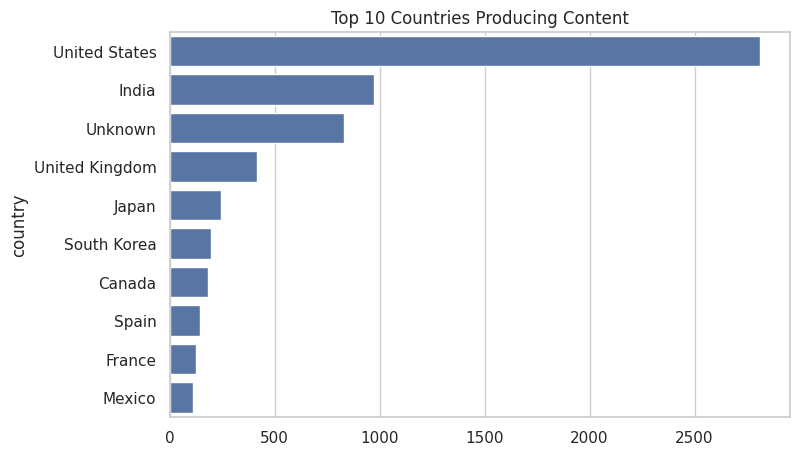

In [ ]:
top_countries = df['country'].value_counts().head(10)

plt.figure(figsize=(8,5))
sns.barplot(x=top_countries.values, y=top_countries.index)
plt.title("Top 10 Countries Producing Content")
plt.show()

## **Graph showing Top 10 Genres**

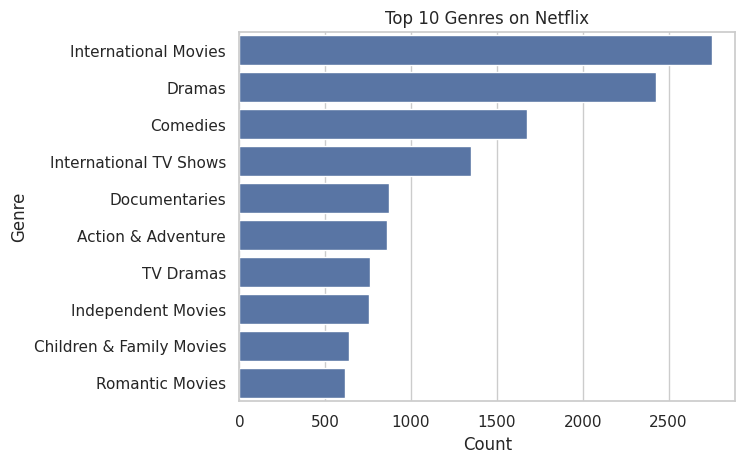

In [ ]:
from collections import Counter

genres = df['listed_in'].str.split(', ')
genre_list = []

for sublist in genres:
    genre_list.extend(sublist)

genre_counts = Counter(genre_list)
top_genres = pd.DataFrame(genre_counts.most_common(10), columns=['Genre','Count'])

sns.barplot(data=top_genres, x='Count', y='Genre')
plt.title("Top 10 Genres on Netflix")
plt.show()

## **Graph showing Distribution of Content Ratings**

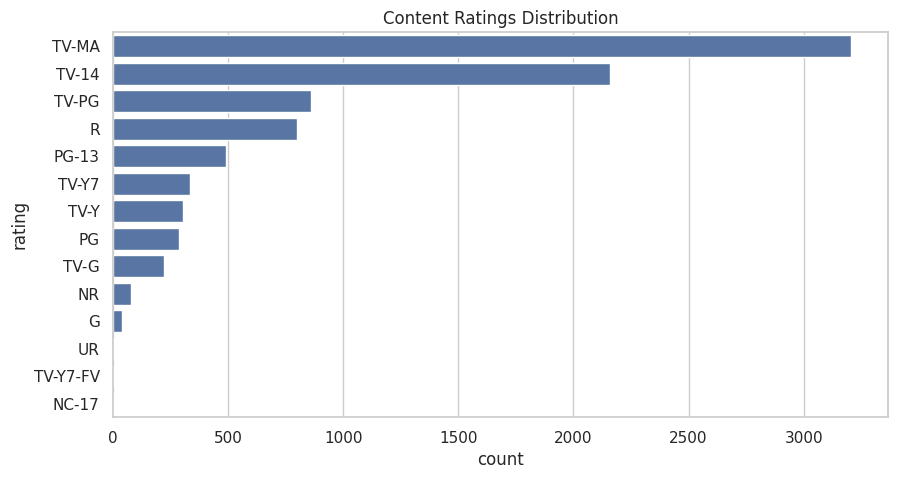

In [ ]:
plt.figure(figsize=(10,5))
sns.countplot(data=df, y='rating', order=df['rating'].value_counts().index)
plt.title("Content Ratings Distribution")
plt.show()

## **Graph showing the Trend of the Type of Content over the Years**

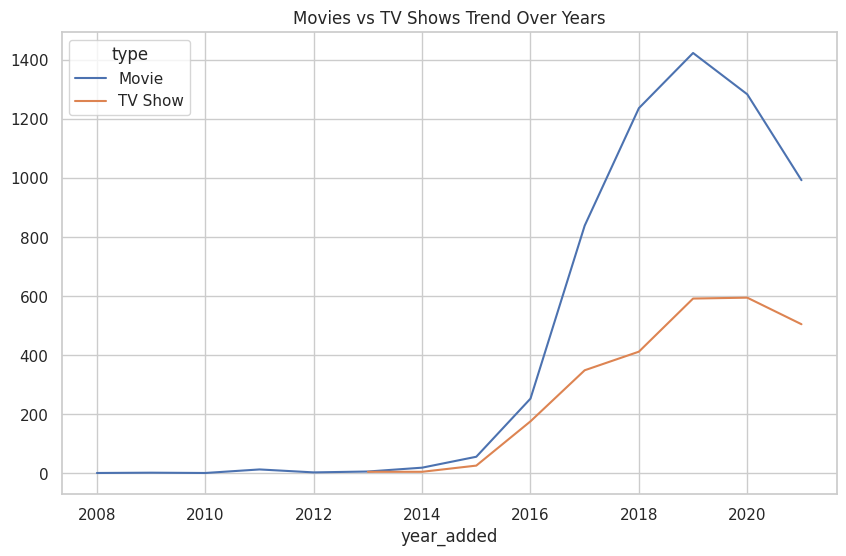

In [ ]:
type_trend = df.groupby(['year_added','type']).size().unstack()

type_trend.plot(figsize=(10,6))
plt.title("Movies vs TV Shows Trend Over Years")
plt.show()

## **Graph showing Distribution of Movies with respect to Duration:Minutes**

In [ ]:
movies = df[df['type'] == 'Movie'].copy()

movies['duration_int'] = movies['duration'].str.extract('(\d+)')
movies['duration_int'] = movies['duration_int'].astype(int)

<>:3: SyntaxWarning: invalid escape sequence '\d'
<>:3: SyntaxWarning: invalid escape sequence '\d'
/tmp/ipykernel_1316/2778886703.py:3: SyntaxWarning: invalid escape sequence '\d'
  movies['duration_int'] = movies['duration'].str.extract('(\d+)')


In [ ]:
bins = [0, 60, 90, 110, 130, 150, 300]
labels = ['<60', '60-90', '90-110', '110-130', '130-150', '150+']

movies['duration_group'] = pd.cut(
    movies['duration_int'],
    bins=bins,
    labels=labels
)

/tmp/ipykernel_1316/3524371625.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


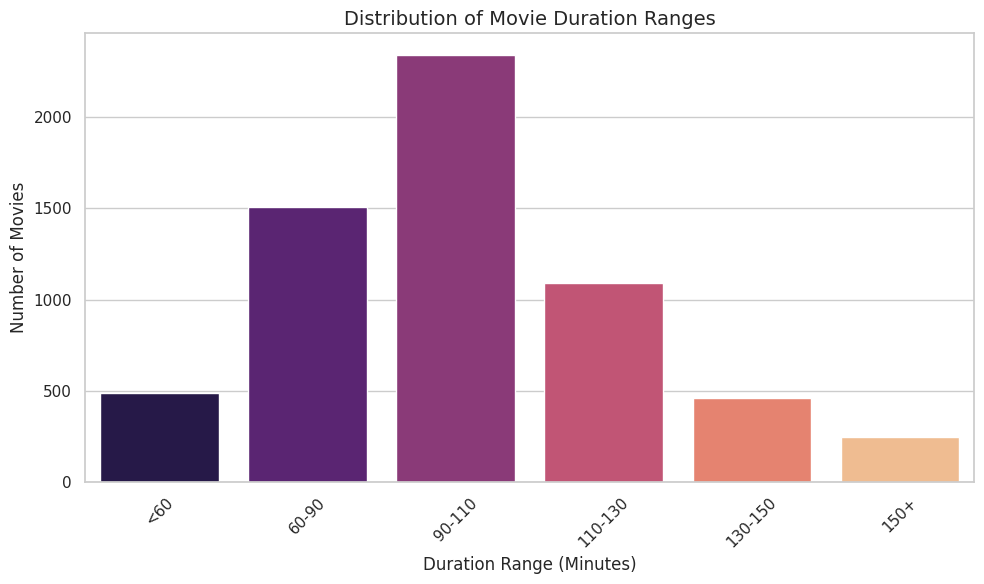

In [ ]:
plt.figure(figsize=(10,6))

order = labels

sns.countplot(
    data=movies,
    x='duration_group',
    order=order,
    palette='magma'
)

plt.title("Distribution of Movie Duration Ranges", fontsize=14)
plt.xlabel("Duration Range (Minutes)")
plt.ylabel("Number of Movies")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## **Graph showing Distribution of TV Shows with respect to Duration:Seasons**

In [ ]:
tv = df[df['type'] == 'TV Show'].copy()

tv['seasons'] = tv['duration'].str.extract('(\d+)')
tv['seasons'] = tv['seasons'].astype(int)

<>:3: SyntaxWarning: invalid escape sequence '\d'
<>:3: SyntaxWarning: invalid escape sequence '\d'
/tmp/ipykernel_1316/527180085.py:3: SyntaxWarning: invalid escape sequence '\d'
  tv['seasons'] = tv['duration'].str.extract('(\d+)')


In [ ]:
bins = [0, 1, 2, 3, 4, 5, 20]
labels = ['1', '2', '3', '4', '5', '6+']

tv['season_group'] = pd.cut(
    tv['seasons'],
    bins=bins,
    labels=labels
)

/tmp/ipykernel_1316/610572817.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


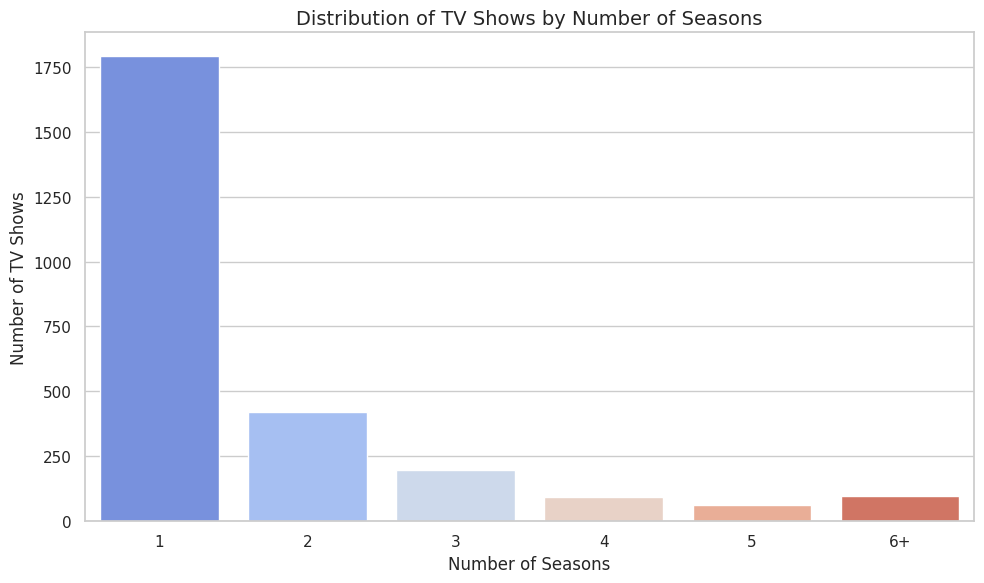

In [ ]:
plt.figure(figsize=(10,6))

sns.countplot(
    data=tv,
    x='season_group',
    order=labels,
    palette='coolwarm'
)

plt.title("Distribution of TV Shows by Number of Seasons", fontsize=14)
plt.xlabel("Number of Seasons")
plt.ylabel("Number of TV Shows")
plt.tight_layout()
plt.show()

## **Word Cloud of Themes in Description**

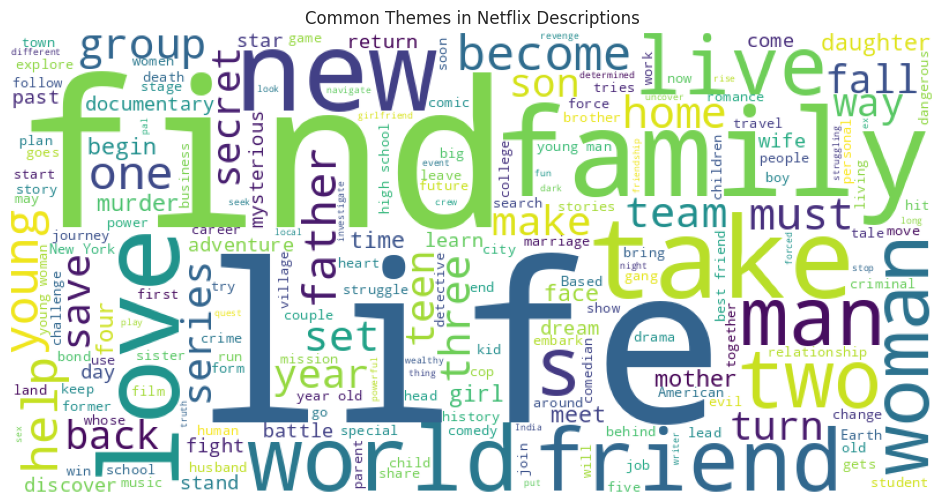

In [ ]:
from wordcloud import WordCloud

text = " ".join(df['description'])

wordcloud = WordCloud(width=800, height=400, background_color='white').generate(text)

plt.figure(figsize=(12,6))
plt.imshow(wordcloud)
plt.axis('off')
plt.title("Common Themes in Netflix Descriptions")
plt.show()

# **Using K-Means Clustering to Analyse Different Content Groups**

In [ ]:
df_cluster = df.copy()

# Extract numeric duration
df_cluster['duration_int'] = df_cluster['duration'].str.extract('(\d+)')
df_cluster['duration_int'] = df_cluster['duration_int'].astype(float)

# Create is_movie feature
df_cluster['is_movie'] = np.where(df_cluster['type']=='Movie', 1, 0)

<>:4: SyntaxWarning: invalid escape sequence '\d'
<>:4: SyntaxWarning: invalid escape sequence '\d'
/tmp/ipykernel_1316/653311823.py:4: SyntaxWarning: invalid escape sequence '\d'
  df_cluster['duration_int'] = df_cluster['duration'].str.extract('(\d+)')


In [ ]:
df_cluster['num_genres'] = df_cluster['listed_in'].str.split(', ').apply(len)

In [ ]:
df_cluster['rating_encoded'] = df_cluster['rating'].astype('category').cat.codes

In [ ]:
features = df_cluster[['duration_int',
                       'release_year',
                       'num_genres',
                       'rating_encoded']].dropna()

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
scaled_features = scaler.fit_transform(features)

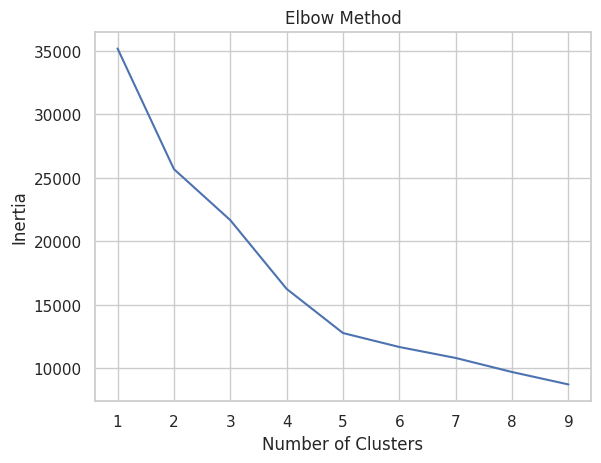

In [ ]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

inertia = []

for k in range(1,10):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(scaled_features)
    inertia.append(kmeans.inertia_)

plt.plot(range(1,10), inertia)
plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.show()

In [ ]:
kmeans = KMeans(n_clusters=4, random_state=42)
features['cluster'] = kmeans.fit_predict(scaled_features)

In [ ]:
cluster_summary = features.groupby('cluster').mean()
cluster_summary

,duration_int,release_year,num_genres,rating_encoded
cluster,,,,
0,3.357724,2017.082204,2.614724,7.726739
1,57.100733,2016.697800,1.127139,7.986308
2,107.857880,2015.384576,2.515863,6.421976
3,110.033283,1989.650530,2.201210,5.134644


## **Using PCA for better Cluster Visualisation**

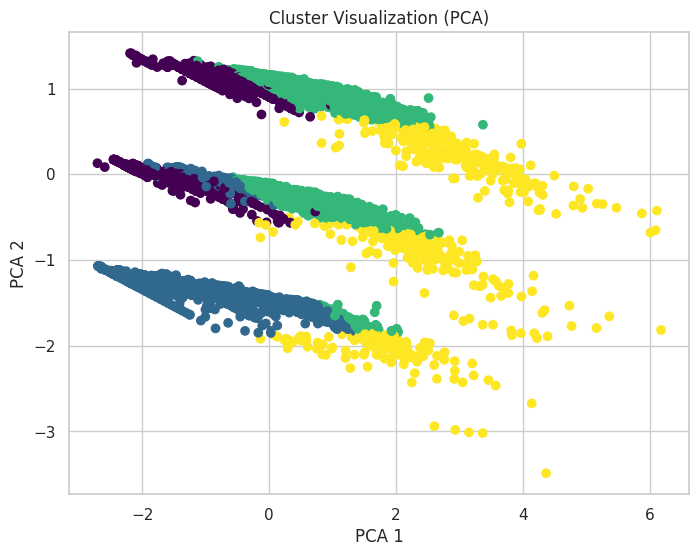

In [ ]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
components = pca.fit_transform(scaled_features)

plt.figure(figsize=(8,6))
plt.scatter(components[:,0], components[:,1],
            c=features['cluster'], cmap='viridis')
plt.title("Cluster Visualization (PCA)")
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.show()

## **Growth of Clusters with respect to Years**

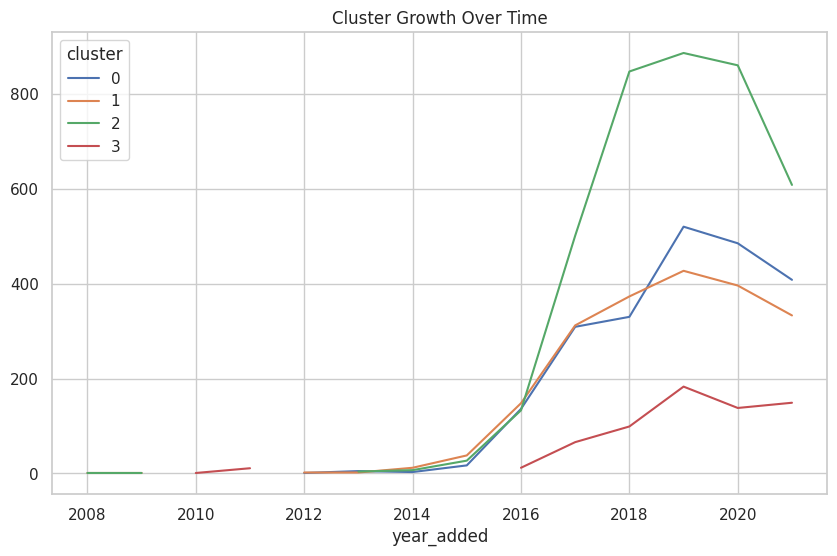

In [ ]:
df_cluster['cluster'] = features['cluster']

growth = df_cluster.groupby(['year_added','cluster']).size().unstack()
growth.plot(figsize=(10,6))
plt.title("Cluster Growth Over Time")
plt.show()

## **Proportion of Values in each Cluster**

In [ ]:
features['cluster'].value_counts(normalize=True) * 100

,proportion
cluster,
2,44.071843
0,25.167671
1,23.246561
3,7.513925
